## **Описание проекта: оценка рисков невозврата кредита**

В вашем распоряжении данные клиентов банка «Скрудж», которые планируют взять кредит. Вам необходимо выяснить, что из имеющихся данных влияет на своевременное погашение кредита и каким именно образом.

Исследование поможет в создании модели кредитного скоринга — системы для оценки способности потенциального заёмщика погасить свой кредит.

По каждому клиенту есть информация о его семейном положении, образовании, доходе и другие данные. Вам предстоит подготовить данные к анализу и исследовать их, в процессе отвечая на вопросы.

### Описание данных

- `children` — количество детей в семье;
- `days_employed` — сколько дней работает клиент;
- `dob_years` — возраст клиента;
- `education` — уровень образования клиента;
- `education_id` — идентификатор образования клиента;
- `family_status` — семейное положение клиента;
- `family_status_id` — идентификатор семейного положения клиента;
- `gender` — пол клиента;
- `income_type` — тип дохода клиента;
- `debt` — был ли у клиента когда-либо просрочен платёж по кредиту;
- `total_income` — ежемесячный доход;
- `purpose` — причина оформления кредита.




## Шаг 1. Откройте файл с данными и изучите общую информацию

1. Загрузите датасет.
2. Сделайте копию датасета.
3. Изучите типы данных и определите, соответствуют ли они содержимому. 
4. Напишите вывод.



In [1]:
# Импортируйте библиотеки для работы
# с таблицами и графиками
import pandas as pd             
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Загрузите датасет в переменную df_raw или другую по вашему выбору.
# Он доступен по адресу <https://code.s3.yandex.net/datasets/credit_scoring_eng.csv>
# а при работе на платформе по адресу /datasets/credit_scoring_eng.csv
df_raw = pd.read_csv('/datasets/credit_scoring_eng.csv')



In [3]:
# При помощи метода .copy() скопируйте датасет
# для работы с ним в переменную df или другую
df = df_raw.copy()



In [4]:
# Изучите общую информацию о датасете
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
count,21525.000000,19351.000000,21525.000000,21525.000000,21525.000000,21525.000000,19351.000000
mean,0.538908,63046.497661,43.293380,0.817236,0.972544,0.080883,26787.568355
std,1.381587,140827.311974,12.574584,0.548138,1.420324,0.272661,16475.450632
min,-1.000000,-18388.949901,0.000000,0.000000,0.000000,0.000000,3306.762000
25%,0.000000,-2747.423625,33.000000,1.000000,0.000000,0.000000,16488.504500
50%,0.000000,-1203.369529,42.000000,1.000000,0.000000,0.000000,23202.870000
75%,1.000000,-291.095954,53.000000,1.000000,1.000000,0.000000,32549.611000
max,20.000000,401755.400475,75.000000,4.000000,4.000000,1.000000,362496.645000


## Анализ вывода общей информации выявляет несколько критических аномалий:
### children: Присутствуют аномалии — отрицательное значение (-1) и очень высокие (20). Эти значения выглядят как ошибки ввода.
### days_employed: отрицательные значения и аномальные максимумы. Максимальное значение 401755 дней — это около 1100 лет, что физически невозможно.
### dob_years: Минимальный возраст равен 0. Это явная ошибка в данных, так как кредит выдается совершеннолетним.
### total_income: Среднее (26787) заметно выше медианы (23202). Это говорит о наличии выбросов, которые тянут среднее вверх.



## Шаг 2. Выполните предобработку данных




1. Найдите и изучите пропущенные значения в столбцах. 
2. Устраните пропущенные значения: удалите или замените их. 
3. Объясните выбранную стратегию обработки пропущенных значений.



In [5]:
# Подсчет пропущенных значений
print(df.isna().sum())

# Заполнение пропусков в total_income медианой
df['total_income'] = df['total_income'].fillna(df['total_income'].median())
df['days_employed'] = df['days_employed'].fillna(df['days_employed'].median())

# Проверка результата
print(df.isna().sum())

children               0
days_employed       2174
dob_years              0
education              0
education_id           0
family_status          0
family_status_id       0
gender                 0
income_type            0
debt                   0
total_income        2174
purpose                0
dtype: int64
children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64


## Подсчет пропущенных значений и их заполнение:
### Мы видим, что кол-во пропусков 2174 в столбцах (days_employed, total_income) совпадает. 
Это может указывать на одних и тех же клиентов, которые не предоставили данные о своей работе.
### Заполнение пропусков в total_income медианой
#### Почему не удаление: мы потеряем около 10% данных (2174 из 21525), что может исказить результаты исследования
#### Почему медиана: медиана устойчива к выбросам в отличие от среднего


1. Изучите уникальные значения в столбцах с уровнем образования (`education`) и полом клиента (`gender`). 
2. Устраните неявные дубликаты и некорректные значения.



In [6]:
print(df['education'].unique())
print(df['gender'].unique())

# Приводим все значения в столбце education к нижнему регистру
df['education'] = df['education'].str.lower()

# Удаляем строку с аномальным значением 'XNA' в столбце gender, 
# так как оно единично и не поддается идентификации
df = df[df['gender'] != 'XNA']

print(df['education'].unique())
print(df['gender'].unique())


["bachelor's degree" 'secondary education' 'Secondary Education'
 'SECONDARY EDUCATION' "BACHELOR'S DEGREE" 'some college'
 'primary education' "Bachelor's Degree" 'SOME COLLEGE' 'Some College'
 'PRIMARY EDUCATION' 'Primary Education' 'Graduate Degree'
 'GRADUATE DEGREE' 'graduate degree']
['F' 'M' 'XNA']
["bachelor's degree" 'secondary education' 'some college'
 'primary education' 'graduate degree']
['F' 'M']



1. Проверьте наличие дубликатов. Изучите дублированные данные, если они есть, и примите решение — удалять их или оставить.



In [7]:
print(f"Количество дубликатов: {df.duplicated().sum()}")

# Изучение дублированных данных по первым строкам. Найдены полные дубликаты
print(df[df.duplicated()].head())

# Удаление дубликатов и обновление индексов
df = df.drop_duplicates().reset_index(drop=True)

print(f"Количество дубликатов после очистки: {df.duplicated().sum()}")



Количество дубликатов: 71
      children  days_employed  dob_years            education  education_id  \
2849         0   -1203.369529         41  secondary education             1   
3290         0   -1203.369529         58  secondary education             1   
4182         1   -1203.369529         34    bachelor's degree             0   
4851         0   -1203.369529         60  secondary education             1   
5557         0   -1203.369529         58  secondary education             1   

          family_status  family_status_id gender income_type  debt  \
2849            married                 0      F    employee     0   
3290  civil partnership                 1      F     retiree     0   
4182  civil partnership                 1      F    employee     0   
4851  civil partnership                 1      F     retiree     0   
5557  civil partnership                 1      F     retiree     0   

      total_income                              purpose  
2849      23202.87  

## Дубликаты необходимо удалить. Обоснование:

### В данных нет уникальных идентификаторов пользователей (например, ID или ФИО).
### Вероятность того, что у двух разных людей полностью совпадут возраст, доход (вплоть до копеек), стаж, количество детей, цель кредита и образование, крайне мала.
### Скорее всего это ошибки при выгрузке данных.



## Шаг 3. Выбросы и аномальные значения

Изучите столбцы `total_income`, `dob_age`, `chidlren` на наличие выбросов и аномальных значений, в том числе при помощи графиков. Если выбросы или аномалии будут обнаружены — обоснованно примите решение об их судьбе. Используйте подзаголовки третьего уровня (`### Подзаголовок`), чтобы создать структуру действий в рамках этого шага.



## 1. Проверка уникальных значений

### Проверка распределения по количеству детей
print(df['children'].value_counts())
### Проверка распределения по возрасту
res = df['dob_years'].value_counts().sort_index()
print(res.head(), res.tail())
### Проверка распределения по возрасту
print(df['total_income'].sort_values().tail())

## 2. Визуализация значений. Поиск выбросов

### Визуализация распределения по количеству детей. Используем столбчатую диаграмму.
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='children')
plt.title('Распределение количества детей')
plt.xlabel('Количество детей')
plt.ylabel('Количество клиентов')
plt.show()

### Проверка распределения возраста. Используем гистограмму.
sns.histplot(df['dob_years'], bins=30)
plt.title('Распределение возраста клиентов')
plt.show()

### Исследование дохода (total_income).

#### Построение boxplot для дохода
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['total_income'])

#### Добавляем линию среднего значения (красная пунктирная)
plt.axvline(df['total_income'].mean(), color='red', linestyle='--')

#### Добавляем линию медианы (зеленая сплошная)
plt.axvline(df['total_income'].median(), color='green', linestyle='-')
plt.show()

## 3. Решение по выбросам и аномальным значениям

### Решение по замене аномальных значений(кол-во детей)

#### Скорее всего, опечатка (тире перед единицей). Заменим на 1.
df['children'] = df['children'].replace(-1, 1)
#### Неправдоподобный всплеск (у 76 человек ровно 20 детей, при этом нет никого с 6-19 детьми).
#### Вероятно лишний ноль. Заменим на 2.
df['children'] = df['children'].replace(20, 2)

### Решение по замене аномальных значений(возраст)
#### Возраст 0 — явная ошибка. Таких строк 101. Заменим их на медиану, чтобы не терять данные других столбцов клиентов.
df.loc[df['dob_years'] == 0, 'dob_years'] = df['dob_years'].median()

### Решение по аномальным значениям(доход)

#### Перед принятием решения по замене, удалению или оставлению выбросов стоит посмотреть на клиентов со сверхвысокими прибылями.
print(df[df['total_income'] > 300000])
#### Таких всего 2. Оба мужчины средних лет, занимаются бизнесом и берут кредит на недвижимость/ремонт. Выглядет реалистично.
#### Однако, учитывая, что их всего двое на 21 тысячу записей и между ними и остальными клиентами огромный разрыв, они могут смещать средние показатели в анализе.
####  Если мы хотим видеть более приближенную к медиане среднюю доходность клиентов, принято решение удалить эти две аномальные строки.
df = df[df['total_income'] < 350000].reset_index(drop=True)



## Шаг 4. Добавьте в таблицу новые столбцы




1. **Разделите клиентов на 5 категорий по уровню дохода:**
- Без дохода — люди без работы и с нулевым доходом.
- Очень низкий доход — люди, получающие ниже 14 процентиля от общего распределения дохода.
- Низкий доход — люди, получающие между 14 и 34 процентилями от общего распределения дохода.
- Средний доход — люди, получающие между 34 и 78 процентилями от общего распределения дохода.
- Высокий доход — люди, получающие больше 78 процентиля от общего распределения дохода.



In [8]:
# Рассчитываем границы категорий по квантилю
q14 = df['total_income'].quantile(0.14)
q34 = df['total_income'].quantile(0.34)
q78 = df['total_income'].quantile(0.78)

# Функция для сегментации
def income_category(income):
    if income == 0:
        return 'Без дохода'
    if income < q14:
        return 'Очень низкий доход'
    if income < q34:
        return 'Низкий доход'
    if income < q78:
        return 'Средний доход'
    return 'Высокий доход'

# Создание нового столбца
df['income_group'] = df['total_income'].apply(income_category)

# Проверка распределения по категориям
print(df['income_group'].value_counts())



Средний доход         9439
Высокий доход         4720
Низкий доход          4290
Очень низкий доход    3004
Name: income_group, dtype: int64



1. Разделите клиентов на две категории по возрасту: до 40 лет и после. Сохраните результат в колонке `age_category`.



In [9]:
def age_group(age):
    if age < 40:
        return 'до 40 лет'
    return 'после 40 лет'

# Создание нового столбца
df['age_category'] = df['dob_years'].apply(age_group)

# Проверка распределения
print(df['age_category'].value_counts())



после 40 лет    12511
до 40 лет        8942
Name: age_category, dtype: int64



1. Разделите клиентов на несколько категорий по количеству детей: без детей, от одного до двух, от трёх и больше. Сохраните результат в колонке `childrens_category`.



In [10]:

def children_group(children):
    if children == 0:
        return 'без детей'
    if 1 <= children <= 2:
        return 'от одного до двух'
    return 'от трёх и больше'

# Создание нового столбца
df['childrens_category'] = df['children'].apply(children_group)

# Проверка распределения клиентов по новым категориям
print(df['childrens_category'].value_counts())


без детей            14090
от одного до двух     6860
от трёх и больше       503
Name: childrens_category, dtype: int64



## Шаг 5. Проведите исследовательский анализ данных




Задайте структуру наиболее объёмной части исследования. Исследуйте факторы: `Уровень дохода`, `Образование`, `Возраст`, `Количество детей`. Отличается ли распределение между должниками и нет? Исследуйте вопрос графически. Постройте сводную таблицу по каждому фактору и покажите, как часто встречаются должники в каждой группе клиентов. Выберите подходящую визуализацию и сравните 2 группы.



--- Анализ фактора: Уровень дохода ---
                    Всего клиентов  Количество должников  Доля должников
income_group                                                            
Средний доход                 9439                   814        0.086238
Низкий доход                  4290                   369        0.086014
Очень низкий доход            3004                   229        0.076232
Высокий доход                 4720                   329        0.069703




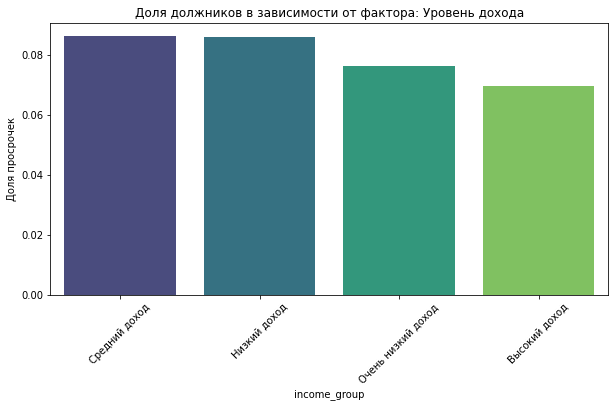

--- Анализ фактора: Образование ---
                     Всего клиентов  Количество должников  Доля должников
education                                                                
primary education               282                    31        0.109929
some college                    743                    68        0.091521
secondary education           15172                  1364        0.089902
bachelor's degree              5250                   278        0.052952
graduate degree                   6                     0        0.000000




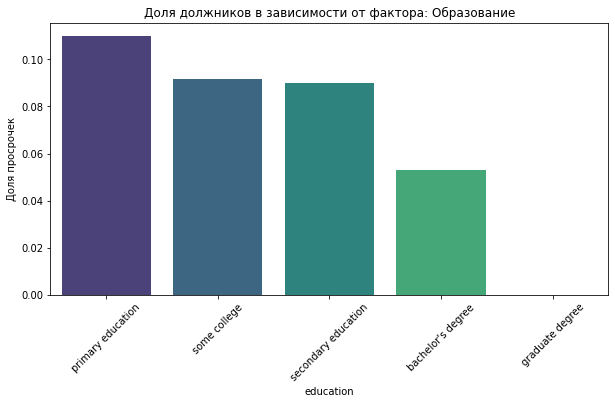

--- Анализ фактора: Возраст ---
              Всего клиентов  Количество должников  Доля должников
age_category                                                      
до 40 лет               8942                   909        0.101655
после 40 лет           12511                   832        0.066501




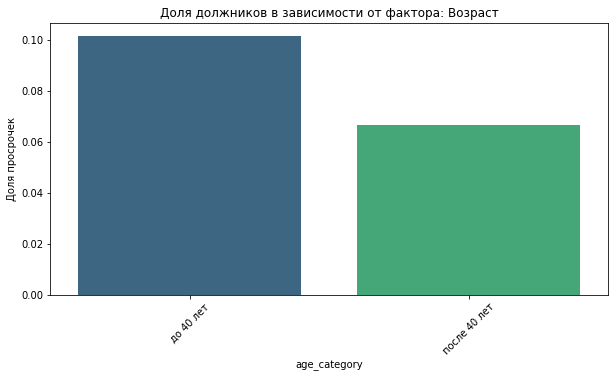

--- Анализ фактора: Количество детей ---
                    Всего клиентов  Количество должников  Доля должников
childrens_category                                                      
от одного до двух             6860                   638        0.093003
от трёх и больше               503                    40        0.079523
без детей                    14090                  1063        0.075444




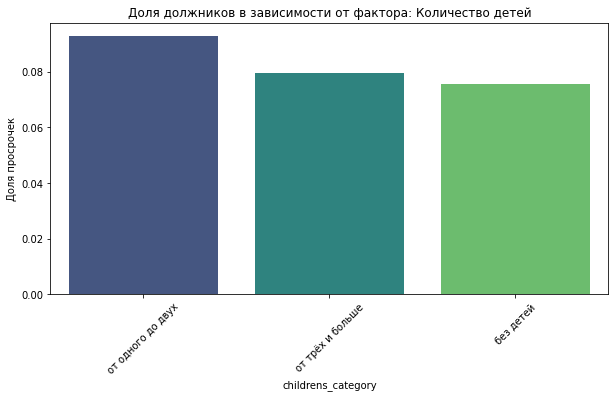

In [11]:
# Универсальная функция для создания сводных таблиц и графиков
def analyze_factor(df, column, title):
    # Сводная таблица
    pivot = df.pivot_table(index=column, values='debt', aggfunc=['count', 'sum', 'mean'])
    pivot.columns = ['Всего клиентов', 'Количество должников', 'Доля должников']
    pivot = pivot.sort_values(by='Доля должников', ascending=False)
    
    print(f"--- Анализ фактора: {title} ---")
    print(pivot)
    print("\n")
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    sns.barplot(x=pivot.index, y=pivot['Доля должников'], palette='viridis')
    plt.title(f'Доля должников в зависимости от фактора: {title}')
    plt.ylabel('Доля просрочек')
    plt.xticks(rotation=45)
    plt.show()

# 1. Анализ уровня дохода
analyze_factor(df, 'income_group', 'Уровень дохода')

# 2. Анализ образования
analyze_factor(df, 'education', 'Образование')

# 3. Анализ возраста
analyze_factor(df, 'age_category', 'Возраст')

# 4. Анализ количества детей
analyze_factor(df, 'childrens_category', 'Количество детей')



## Выводы по анализам данных графиков:
### Анализ уровня дохода
Анализ уровня дохода показал, что доля должников наибольшая у клиентов с высоким уровнем дохода. Практически такая же доля у клиентов с низким доходом. Далее идут очень низкий доход, высокий доход. Можно предположить о некоторой осторожности в выборе размера кредита у клиентов с очень низким уровнем дохода, о социальной поддержке государства, а также о политике банка, когда кредиты одобряют только клиентам с идеальной кредитной историей.
### Анализ образования
Анализ образования показал в целом положительную зависимость кредитоспособности клиента от его уровня образования.
### Анализ возраста
Клиенты до 40 чаще оказываются должниками. Это можно объяснить некоторой осторожностью и финансовой стабильностью у более возрастных клиентов и готовностью идти на риск у более молодых.
### Анализ количества детей
Доля просрочек с количеством детей от одного до двух больше всего. Далее идут от 3 и более. Меньше всего среди бездетных.
Появление 1–2 детей резко увеличивает непланируемые расходы семьи (медицина, образование, одежда, питание). Бюджет становится менее гибким.


***Проверьте исследовательскую гипотезу***: у клиентов с детьми более высокий уровень финансовой ответственности и, следовательно, более низкий риск просрочек по кредиту.



                    Всего клиентов  Количество должников  Доля просрочки
childrens_category                                                      
без детей                    14090                  1063        0.075444
от трёх и больше               503                    40        0.079523
от одного до двух             6860                   638        0.093003


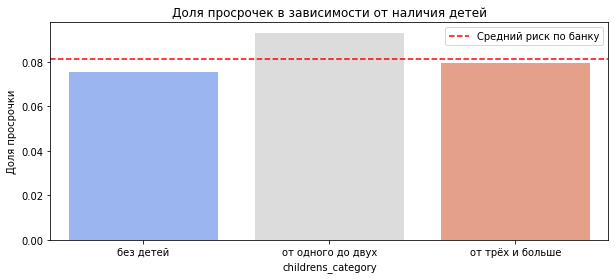

In [12]:
# Создаем сводную таблицу по категориям детей
children_pivot = df.pivot_table(index='childrens_category', values='debt', aggfunc=['count', 'sum', 'mean'])
children_pivot.columns = ['Всего клиентов', 'Количество должников', 'Доля просрочки']

# Сортируем для наглядности
print(children_pivot.sort_values(by='Доля просрочки'))

# Визуализация для сравнения рисков
plt.figure(figsize=(10, 4))
sns.barplot(x=children_pivot.index, y=children_pivot['Доля просрочки'], palette='coolwarm')
plt.title('Доля просрочек в зависимости от наличия детей')
plt.axhline(df['debt'].mean(), color='red', linestyle='--', label='Средний риск по банку')
plt.legend()
plt.show()



## Опровержение гипотезы
Клиенты без детей часто либо очень молоды, либо, что важнее, находятся в зрелом возрасте, когда карьера стабильна, а дети уже выросли. Родители с 1–2 детьми — это преимущественно люди в возрасте от 25 до 40 лет. Как мы выяснили ранее, эта возрастная группа сама по себе более рискованная из-за нестабильности доходов и высокой общей закредитованности (ипотека + автокредит + дет. сад/школа).
### Почему у многодетных (3+) риск чуть ниже, чем у семей с 1-2 детьми?
Хотя их риск всё равно выше, чем у бездетных, небольшое снижение относительно семей с 1–2 детьми часто можно объяснить государственной поддержкой:
#### Льготные программы рефинансирования
#### Социальные выплаты и субсидии
#### Повышенная дисциплина


***Проверьте исследовательскую гипотезу***: одинокие мужчины с низким доходом чаще оказываются должниками, чем семейные мужчины со средним доходом.



Доля просрочек у одиноких мужчин с низким доходом: 11.54%
Доля просрочек у семейных мужчин со средним доходом: 10.56% 



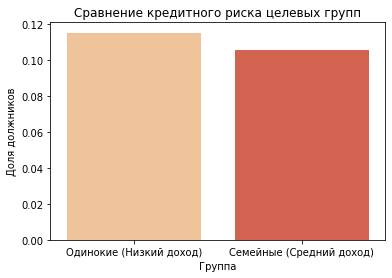

In [13]:
# Фильтруем данные только по мужчинам
men_df = df[df['gender'] == 'M']

# Определяем первую группу: одинокие с низким доходом
# (к одиноким отнесем статусы 'single / not married', 'divorced', 'widow / widower')
lonely_statuses = ['single / not married', 'divorced', 'widow / widower']
group_1 = men_df[
    (men_df['family_status'].isin(lonely_statuses)) & 
    (men_df['income_group'] == 'Низкий доход')
]

# Определяем вторую группу: семейные со средним доходом
# (статусы 'married' или 'civil partnership')
family_statuses = ['married', 'civil partnership']
group_2 = men_df[
    (men_df['family_status'].isin(family_statuses)) & 
    (men_df['income_group'] == 'Средний доход')
]

# Считаем среднюю долю просрочки для каждой группы
risk_1 = group_1['debt'].mean()
risk_2 = group_2['debt'].mean()

print(f"Доля просрочек у одиноких мужчин с низким доходом: {risk_1:.2%}")
print(f"Доля просрочек у семейных мужчин со средним доходом: {risk_2:.2%} \n")

# Визуализация для сравнения
comparison = pd.DataFrame({
    'Группа': ['Одинокие (Низкий доход)', 'Семейные (Средний доход)'],
    'Доля должников': [risk_1, risk_2]
})

sns.barplot(data=comparison, x='Группа', y='Доля должников', palette='OrRd')
plt.title('Сравнение кредитного риска целевых групп')
plt.show()



## Подтверждение гипотезы
### Отсутствие поддержки супруги
    В семейных парах бюджет часто формируется из двух источников. Если у одного из супругов возникают временные трудности с работой, доход второго помогает закрыть платеж по кредиту. Одинокий мужчина в случае финансового шока остается с проблемой один на один.
### Эффект стабилизации
    Психологически семейные люди со средним доходом более склонны к долгосрочному планированию. Наличие семьи и стабильного (среднего) заработка дисциплинирует.
### Сочетание факторов риска
    Здесь работает накладывающийся эффект. Низкий доход сам по себе — фактор нестабильности, а отсутствие семейного статуса лишает заемщика социальной и финансовой подстраховки.



## Шаг 6. Напишите общий вывод



### Главный вывод исследования
    На основе проведенного анализа факторов риска для банка «Скрудж» можно сформировать портрет идеального заёмщика и группу максимального риска.
#### Наиболее надёжный заёмщик: 
    Это клиент старше 40 лет, имеющий высшее образование (в идеале — ученую степень), высокий уровень дохода и не имеющий детей. Отсутствие финансовой нагрузки в виде иждивенцев и наличие стабильного высокого заработка в сочетании с жизненным опытом делают эту категорию самой дисциплинированной.
#### Группа повышенного риска:
    Образование — ключевой маркер. Самый высокий риск невозврата наблюдается у клиентов с начальным образованием. Это более значимый фактор, чем уровень дохода.  Наличие детей, вопреки гипотезе об ответственности, увеличивает риск просрочки. 
    Самая уязвимая группа — родители без высшего образования, с низкими доходами и с 1–2 детьми.



## *Шаг 7. Проведите дополнительное исследование




(Необязательное задание) Исследуйте причины оформления кредита. Правда ли, что люди, которые брали кредит на образование, реже всего оказывались должниками?



In [14]:
# Пример функции для категоризации целей
def categorize_purpose(row):
    if 'educ' in row:
        return 'образование'
    if 'wed' in row:
        return 'свадьба'
    if 'hous' in row or 'real estate' in row or 'prop' in row:
        return 'недвижимость'
    if 'car' in row:
        return 'автомобиль'
    return 'прочее'

df['purpose_category'] = df['purpose'].apply(categorize_purpose)

# Сводная таблица по целям кредита
purpose_pivot = df.pivot_table(index='purpose_category', values='debt', aggfunc=['count', 'mean'])
purpose_pivot.columns = ['Количество кредитов', 'Доля просрочки']
print(purpose_pivot.sort_values(by='Доля просрочки'))



                  Количество кредитов  Доля просрочки
purpose_category                                     
недвижимость                    10810        0.072340
свадьба                          2324        0.080034
прочее                            496        0.086694
образование                      3517        0.092977
автомобиль                       4306        0.093590


Неправда. Доля просрочки наименьшая у тех, кто брал ипотечный кредит.


In [15]:
# Разделите клиентов на 2 группы
def find_education_purpose(purpose):
    if 'educ' in purpose.lower():
        return 'образование'
    return 'другие цели'

# Создание нового столбца
df['is_education'] = df['purpose'].apply(find_education_purpose)

# Сводная таблица для сравнения долей просрочки
edu_hypothesis_pivot = df.pivot_table(index='is_education', values='debt', aggfunc=['count', 'mean'])
edu_hypothesis_pivot.columns = ['Количество клиентов', 'Доля просрочки']

print(edu_hypothesis_pivot)



              Количество клиентов  Доля просрочки
is_education                                     
другие цели                 17936        0.078836
образование                  3517        0.092977


Доля просрочки в группе "образование" выше


  Группа по цели  Всего клиентов  Доля просрочки
0    другие цели           17936        0.078836
1    образование            3517        0.092977


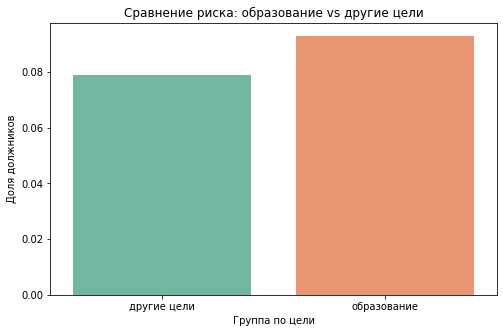

In [16]:
# Группировка данных и расчет среднего (доли просрочки)
edu_comparison = df.groupby('is_education')['debt'].agg(['count', 'mean']).reset_index()
edu_comparison.columns = ['Группа по цели', 'Всего клиентов', 'Доля просрочки']

# Вывод результатов
print(edu_comparison)

# Визуализация разницы
plt.figure(figsize=(8, 5))
sns.barplot(data=edu_comparison, x='Группа по цели', y='Доля просрочки', palette='Set2')
plt.title('Сравнение риска: образование vs другие цели')
plt.ylabel('Доля должников')
plt.show()




---Итог: Гипотеза неверна. Доля должников среди людей, бравших кредит на образование в среднем выше чем доля должников бравших кредит по иным целям.